In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid.csv').drop('Unnamed: 0', axis=1)

In [5]:
df_train = df_pushed_year[df_pushed_year['year']<=2020].copy()
df_val = df_origin[df_origin['year']==2020].copy() # use 2020 data predict for 2021, the df_val_df dataset is in original year
df_val['year']=2021
df_val['Is_Covid']=1
actual_total_y = sum(df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt'])
actual_total_y

109259516579.438

In [9]:
df_2021 = df_origin[df_origin['year']==2021].copy()
actual_total_2022 = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
df_2021['year'] = 2022
df_2021['Is_Covid'] = 0
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

In [6]:
set(df_val.columns.tolist())==set(df_train.columns.tolist())

True

In [7]:
df_cols = df_train.columns.tolist()
df_cols

['Rndrng_NPI',
 'Rndrng_Prvdr_Ent_Cd',
 'Rndrng_Prvdr_State_Abrvtn',
 'Rndrng_Prvdr_Type',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
 'Tot_HCPCS_Cds',
 'Tot_Benes',
 'Tot_Srvcs',
 'Bene_Avg_Age',
 'Bene_Avg_Risk_Scre',
 'pca_1_scaled',
 'Tot_Risk',
 'APP_Tot_Risk',
 'PrimaryCare_Tot_Risk',
 'MedicalSpecialtyOther_Tot_Risk',
 'LabPathology_Tot_Risk',
 'PharmacyNutrition_Tot_Risk',
 'Tot_Mdcr_Pymt_Amt',
 'year',
 'Is_Covid',
 'state']

# Null Model

In [119]:
MODEL_null_no_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    #offset=np.log(df_train["pca_1_scaled"]),
).fit()

In [118]:
MODEL_null_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["pca_1_scaled"]),
).fit()

In [24]:
df_train.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds',
       'Tot_Benes', 'Tot_Srvcs', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre',
       'pca_1_scaled', 'Tot_Risk', 'APP_Tot_Risk', 'PrimaryCare_Tot_Risk',
       'MedicalSpecialtyOther_Tot_Risk', 'LabPathology_Tot_Risk',
       'PharmacyNutrition_Tot_Risk', 'Tot_Mdcr_Pymt_Amt', 'year', 'Is_Covid',
       'state'],
      dtype='object')

# Preprocessing Columns

In [6]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs','Tot_Mdcr_Pymt_Amt','pca_1_scaled']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X_train = pd.concat([df[num_cols+['Tot_Mdcr_Pymt_Amt']],X_cat_df],axis=1)
    return X_train


In [7]:
X_train = enc_df(df_train)
X_val = enc_df(df_val)

In [10]:
df_2021 = enc_df(df_2021)
df_2022 = enc_df(df_2022)

In [11]:
X_train['Tot_Mdcr_Pymt_Amt'] = X_train['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)

# Models without Offset - one feature

In [124]:
RESULT_DF = pd.DataFrame(columns=['formula','val_percentage','train_percentage','val_deviance','pseudo_R^2','offset'])
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset


In [115]:
feature_cols = [c for c in X_train.columns.tolist() if c not in ['Tot_Risk','Tot_Mdcr_Pymt_Amt']]

In [122]:
start = 0

In [ ]:
for i in range(start,len(feature_cols)):
    if feature_cols[i]=='year':
        formula = 'Tot_Mdcr_Pymt_Amt~cr(year,df=3)'
    else: formula = f'Tot_Mdcr_Pymt_Amt~{feature_cols[i]}'

    MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

    y_pred = MODEL.predict(X_val)

    val_p = sum(y_pred)/actual_total_y

    train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

    r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

    val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

    temp = pd.DataFrame({
        'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
        'val_percentage': [val_p],
        'train_percentage': [train_p],
        'val_deviance': [val_d],
        'pseudo_R^2': [r2_dev],
        'offset':['N'],
        'abs_val_percentage':[abs(val_p-1)]
    })
    RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF


/var/folders/46/mjvmwj6x7n5_cdghvmx10bkm0000gn/T/ipykernel_2336/2533955962.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)


,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset
0,[Bene_Avg_Age],1.061682,0.989079,49716.914798,0.073181,N
0,[Bene_Avg_Risk_Scre],1.077821,1.009287,69297.908152,0.016780,N
0,[APP_Tot_Risk],0.991454,1.000000,90659.693985,0.090128,N
0,[PrimaryCare_Tot_Risk],1.032380,1.000000,78882.540743,0.000676,N
0,[MedicalSpecialtyOther_Tot_Risk],1.034754,1.000000,80960.079088,0.000215,N
0,[LabPathology_Tot_Risk],1.036086,1.003213,93830.748879,0.003915,N
0,[PharmacyNutrition_Tot_Risk],1.035148,1.000000,80748.165513,0.000418,N
0,"[cr(year,df=3)]",0.953572,1.000088,79594.185292,0.000496,N
0,[Is_Covid],0.954673,1.000000,79660.543825,0.000679,N
0,[Cd_I],1.022166,1.000000,263162.923011,0.044311,N


In [ ]:
start = interrupt

In [128]:
RESULT_DF['abs_val_percentage'] = abs(RESULT_DF['val_percentage']-1)
RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,[APP_Tot_Risk],0.991454,1.000000,90659.693985,0.090128,N,0.008546
0,[Type_APP],0.990465,1.000000,90907.385115,0.084385,N,0.009535
0,[Cd_I],1.022166,1.000000,263162.923011,0.044311,N,0.022166
0,[Cd_O],1.022166,1.000000,263162.923017,0.044311,N,0.022166
0,[Type_FacilitySupplierProgram],1.027458,1.000000,79276.886631,0.013022,N,0.027458
0,[Type_OncologyHeme],1.030864,1.000000,69333.058361,0.043772,N,0.030864
0,[Type_LabPathology],1.030943,1.000000,217733.458014,0.027216,N,0.030943
0,[Type_MedicalSpecialtyOther],1.031139,1.000000,71541.529942,0.012912,N,0.031139
0,[Type_AcuteCare],1.031403,1.000000,83332.006413,0.004836,N,0.031403
0,[Type_RehabTherapy],1.031508,1.000000,87419.312186,0.022213,N,0.031508


In [132]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winning model

In [ ]:
MODEL = smf.glm(
        formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk',
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

print('2022 ratio = ', sum(MODEL.predict(df_2021))/actual_total_2022)
print('2023 ratio = ', sum(MODEL.predict(df_2022))/actual_total_2023)

2022 ratio =  1.0389962032961875
2023 ratio =  1.0004997230027382


# Model with two features

In [133]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv').drop('Unnamed: 0',axis=1)
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,['APP_Tot_Risk'],0.991454,1.000000,90659.693985,0.090128,N,0.008546
3,['PrimaryCare_Tot_Risk'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
4,['MedicalSpecialtyOther_Tot_Risk'],1.034754,1.000000,80960.079088,0.000215,N,0.034754
5,['LabPathology_Tot_Risk'],1.036086,1.003213,93830.748879,0.003915,N,0.036086
6,['PharmacyNutrition_Tot_Risk'],1.035148,1.000000,80748.165513,0.000418,N,0.035148
7,"['cr(year,df=3)']",0.953572,1.000088,79594.185292,0.000496,N,0.046428
8,['Is_Covid'],0.954673,1.000000,79660.543825,0.000679,N,0.045327
9,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166


In [134]:
start = 0

In [135]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,['APP_Tot_Risk'],0.991454,1.000000,90659.693985,0.090128,N,0.008546
3,['PrimaryCare_Tot_Risk'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
4,['MedicalSpecialtyOther_Tot_Risk'],1.034754,1.000000,80960.079088,0.000215,N,0.034754
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk, state_Northeast]",0.991720,0.999964,90982.165742,0.091342,N,0.008280
0,"[APP_Tot_Risk, state_West]",0.991475,0.999980,90704.694710,0.090142,N,0.008525
0,"[APP_Tot_Risk, state_Territory]",0.992003,0.999974,91210.669992,0.093202,N,0.007997
0,"[APP_Tot_Risk, state_Military]",0.991445,0.999997,90663.681668,0.090139,N,0.008555


In [137]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

In [ ]:
RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk, Type_PrimaryCare]",0.997498,1.000000,102977.577104,0.100181,N,0.002502
0,"[APP_Tot_Risk, Type_OBGYN]",0.993724,1.000000,93056.902632,0.114160,N,0.006276
0,"[APP_Tot_Risk, LabPathology_Tot_Risk]",0.992657,1.002089,103402.217346,0.092502,N,0.007343
0,"[APP_Tot_Risk, state_South]",0.992209,0.999822,91062.477395,0.098276,N,0.007791
0,"[APP_Tot_Risk, state_Territory]",0.992003,0.999974,91210.669992,0.093202,N,0.007997
0,"[APP_Tot_Risk, Type_OncologyHeme]",0.991964,1.000000,78359.229959,0.125584,N,0.008036
0,"[APP_Tot_Risk, Type_APP]",0.991923,1.000000,90550.948323,0.090160,N,0.008077
0,"[APP_Tot_Risk, PrimaryCare_Tot_Risk]",0.991823,1.000000,91065.938852,0.090146,N,0.008177
0,"[APP_Tot_Risk, PharmacyNutrition_Tot_Risk]",0.991820,1.000000,90792.358297,0.090321,N,0.008180
0,"[APP_Tot_Risk, state_Midwest]",0.991795,0.999662,91731.783950,0.095139,N,0.008205


## Check the winning model

In [141]:
def check_winner(formula):
    MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

    print('2022 ratio = ', sum(MODEL.predict(df_2021))/actual_total_2022)
    print('2023 ratio = ', sum(MODEL.predict(df_2022))/actual_total_2023)
    return

In [142]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk+Type_PrimaryCare'
check_winner(formula)

2022 ratio =  1.0467395557696686
2023 ratio =  1.0089334871851139


In [ ]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()

In [144]:
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880941
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                          24.329
Method:                          IRLS   Log-Likelihood:            -9.4678e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3737e+07
Time:                        11:38:58   Pearson chi2:                 1.67e+08
No. Iterations:                     9   Pseudo R-squ. (CS):           0.009080
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.6855      0.002   5074.305      0.000      11.681      11.690
APP_Tot_Risk        -1.5548      0.005   -290.583      0.000      -1.565      -1.544
Type_PrimaryCare    -0.4116      0.005    -82.714      0.000      -0.421      -0.402
====================================================================================
"""

# Model with three features

In [147]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv').drop('Unnamed: 0',axis=1)
RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,['APP_Tot_Risk'],0.991454,1.000000,90659.693985,0.090128,N,0.008546
3,['PrimaryCare_Tot_Risk'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
4,['MedicalSpecialtyOther_Tot_Risk'],1.034754,1.000000,80960.079088,0.000215,N,0.034754
...,...,...,...,...,...,...,...
70,"['APP_Tot_Risk', 'state_Northeast']",0.991720,0.999964,90982.165742,0.091342,N,0.008280
71,"['APP_Tot_Risk', 'state_West']",0.991475,0.999980,90704.694710,0.090142,N,0.008525
72,"['APP_Tot_Risk', 'state_Territory']",0.992003,0.999974,91210.669992,0.093202,N,0.007997
73,"['APP_Tot_Risk', 'state_Military']",0.991445,0.999997,90663.681668,0.090139,N,0.008555


In [150]:
start = 0

In [151]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,['Bene_Avg_Age'],1.061682,0.989079,49716.914798,0.073181,N,0.061682
1,['Bene_Avg_Risk_Scre'],1.077821,1.009287,69297.908152,0.016780,N,0.077821
2,['APP_Tot_Risk'],0.991454,1.000000,90659.693985,0.090128,N,0.008546
3,['PrimaryCare_Tot_Risk'],1.032380,1.000000,78882.540743,0.000676,N,0.032380
4,['MedicalSpecialtyOther_Tot_Risk'],1.034754,1.000000,80960.079088,0.000215,N,0.034754
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk, Type_PrimaryCare, state_Northeast]",0.997658,0.999842,103351.540810,0.101390,N,0.002342
0,"[APP_Tot_Risk, Type_PrimaryCare, state_West]",0.997492,0.999976,103000.329518,0.100184,N,0.002508
0,"[APP_Tot_Risk, Type_PrimaryCare, state_Territory]",0.998110,1.000091,103561.237158,0.103216,N,0.001890
0,"[APP_Tot_Risk, Type_PrimaryCare, state_Military]",0.997488,0.999997,102981.690761,0.100192,N,0.002512


In [152]:
RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN]",1.000618,1.000000,106933.286755,0.125782,N,0.000618
0,"[APP_Tot_Risk, Type_PrimaryCare, state_South]",0.998318,0.999899,103446.623645,0.108376,N,0.001682
0,"[APP_Tot_Risk, Type_PrimaryCare, state_Territory]",0.998110,1.000091,103561.237158,0.103216,N,0.001890
0,"[APP_Tot_Risk, Type_PrimaryCare, LabPathology_...",0.998051,1.001550,115442.440319,0.101907,N,0.001949
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_Anesthesia]",0.998019,1.000000,116794.528284,0.144834,N,0.001981
...,...,...,...,...,...,...,...
61,"['APP_Tot_Risk', 'Type_AcuteCare']",0.985293,1.000000,94648.888893,0.097226,N,0.014707
0,"[APP_Tot_Risk, Type_PrimaryCare, Bene_Avg_Age]",1.016723,0.981996,67501.765800,0.165046,N,0.016723
57,"['APP_Tot_Risk', 'Type_RehabTherapy']",0.983238,1.000000,99892.820585,0.118597,N,0.016762
9,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166


In [154]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check winner

In [153]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk+Type_PrimaryCare+Type_OBGYN'
check_winner(formula)

2022 ratio =  1.0507407004325913
2023 ratio =  1.0140275517159913


In [156]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880940
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          22.886
Method:                          IRLS   Log-Likelihood:            -9.4314e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.3346e+07
Time:                        12:03:17   Pearson chi2:                 1.57e+08
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01210
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.7194      0.002   5144.183      0.000      11.715      11.724
APP_Tot_Risk        -1.5888      0.005   -305.014      0.000      -1.599      -1.579
Type_PrimaryCare    -0.4456      0.005    -91.928      0.000      -0.455      -0.436
Type_OBGYN          -1.9731      0.012   -170.633      0.000      -1.996      -1.950
====================================================================================
"""

# Model with four features

In [157]:
start = 0

In [158]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare','Type_OBGYN']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i


In [164]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk', 'Type_PrimaryCare', 'Type_OBGYN', 'Type_BehavioralHealth']

In [160]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winner

In [171]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk+Type_PrimaryCare+Type_OBGYN+Type_BehavioralHealth'
check_winner(formula)

2022 ratio =  1.0536360016613313
2023 ratio =  1.0191724987417317


In [172]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880939
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                          20.504
Method:                          IRLS   Log-Likelihood:            -9.3671e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.2932e+07
Time:                        13:16:09   Pearson chi2:                 1.41e+08
No. Iterations:                    10   Pseudo R-squ. (CS):            0.01639
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                11.7788      0.002   5248.092      0.000      11.774      11.783
APP_Tot_Risk             -1.6481      0.005   -331.643      0.000      -1.658      -1.638
Type_PrimaryCare         -0.5049      0.005   -109.050      0.000      -0.514      -0.496
Type_OBGYN               -2.0324      0.011   -185.392      0.000      -2.054      -2.011
Type_BehavioralHealth    -1.3820      0.008   -170.751      0.000      -1.398      -1.366
=========================================================================================
"""

# Model with five features

In [166]:
start = 0

In [167]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare','Type_OBGYN','Type_BehavioralHealth']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999967,0.999797,116548.756868,0.153700,N,0.000033
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999936,1.000000,116178.450863,0.152908,N,0.000064
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999933,1.000016,116156.317159,0.152909,N,0.000067
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999928,0.999998,116179.274954,0.152912,N,0.000072
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999928,1.000000,116175.214330,0.152907,N,0.000072
...,...,...,...,...,...,...,...
57,"['APP_Tot_Risk', 'Type_RehabTherapy']",0.983238,1.000000,99892.820585,0.118597,N,0.016762
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.017570,0.987881,84075.209884,0.193797,N,0.017570
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, B...",1.019898,0.984865,72643.571880,0.184449,N,0.019898
9,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166


In [168]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk',
 'Type_PrimaryCare',
 'Type_OBGYN',
 'Type_BehavioralHealth',
 'state_Northeast']

In [173]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

In [174]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,6] * actual_total_y

3566896.550358927

## Check the winner

In [169]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk+Type_PrimaryCare+Type_OBGYN+Type_BehavioralHealth+state_Northeast'
check_winner(formula)

2022 ratio =  1.0538037634573785
2023 ratio =  1.0193622601657302


In [170]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880938
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                          20.410
Method:                          IRLS   Log-Likelihood:            -9.3644e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.2920e+07
Time:                        13:15:36   Pearson chi2:                 1.40e+08
No. Iterations:                    12   Pseudo R-squ. (CS):            0.01655
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                11.7998      0.002   4881.825      0.000      11.795      11.805
APP_Tot_Risk             -1.6497      0.005   -332.689      0.000      -1.659      -1.640
Type_PrimaryCare         -0.5046      0.005   -109.232      0.000      -0.514      -0.496
Type_OBGYN               -2.0286      0.011   -185.475      0.000      -2.050      -2.007
Type_BehavioralHealth    -1.3728      0.008   -169.878      0.000      -1.389      -1.357
state_Northeast          -0.1030      0.004    -24.600      0.000      -0.111      -0.095
=========================================================================================
"""

# Model with six features

In [175]:
start = 0

In [176]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare','Type_OBGYN','Type_BehavioralHealth','state_Northeast']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + state_Northeast + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + state_Northeast + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.000005,0.999884,116447.492705,0.153771,N,0.000005
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999976,0.999798,116552.425186,0.153701,N,0.000024
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999968,0.999795,116553.113626,0.153705,N,0.000032
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.000032,0.999029,118019.222282,0.159864,N,0.000032
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999967,0.999797,116548.756868,0.153700,N,0.000033
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.017418,0.986958,84606.540245,0.195451,N,0.017418
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.017570,0.987881,84075.209884,0.193797,N,0.017570
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, B...",1.019898,0.984865,72643.571880,0.184449,N,0.019898
9,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166


In [177]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk',
 'Type_PrimaryCare',
 'Type_OBGYN',
 'Type_BehavioralHealth',
 'state_Northeast',
 'state_West']

In [178]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

## Check the winner

In [180]:
formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk+Type_PrimaryCare+Type_OBGYN+Type_BehavioralHealth+state_Northeast+state_West'
check_winner(formula)

2022 ratio =  1.0538035796833278
2023 ratio =  1.0193378850867674


In [181]:
MODEL = smf.glm(
        formula = formula,
        data = X_train,
        family = sm.families.Gamma(link=sm.families.links.Log()),
        #offset = np.log(df_train['Tot_Risk'])
    ).fit()
MODEL.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880937
Model Family:                   Gamma   Df Model:                            6
Link Function:                    Log   Scale:                          20.429
Method:                          IRLS   Log-Likelihood:            -9.3650e+07
Date:                Sun, 08 Mar 2026   Deviance:                   1.2919e+07
Time:                        13:38:44   Pearson chi2:                 1.41e+08
No. Iterations:                    14   Pseudo R-squ. (CS):            0.01654
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                11.8081      0.003   4432.150      0.000      11.803      11.813
APP_Tot_Risk             -1.6513      0.005   -332.698      0.000      -1.661      -1.642
Type_PrimaryCare         -0.5053      0.005   -109.325      0.000      -0.514      -0.496
Type_OBGYN               -2.0295      0.011   -185.462      0.000      -2.051      -2.008
Type_BehavioralHealth    -1.3731      0.008   -169.828      0.000      -1.389      -1.357
state_Northeast          -0.1109      0.004    -25.617      0.000      -0.119      -0.102
state_West               -0.0333      0.005     -7.310      0.000      -0.042      -0.024
=========================================================================================
"""

# Model with seven features

In [182]:
start = 0

In [183]:
for i in range(start,len(feature_cols)):
    if feature_cols[i] not in ['APP_Tot_Risk','Type_PrimaryCare','Type_OBGYN','Type_BehavioralHealth','state_Northeast','state_West']:
        if feature_cols[i]=='year':
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + state_Northeast + state_West + cr(year,df=3)'
        else: formula = f'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + state_Northeast + state_West + {feature_cols[i]}'

        MODEL = smf.glm(
            formula = formula,
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

        y_pred = MODEL.predict(X_val)

        val_p = sum(y_pred)/actual_total_y

        train_p = sum(MODEL.predict(X_train))/sum(df_train['Tot_Mdcr_Pymt_Amt'])

        r2_dev = 1 - MODEL.deviance / MODEL_null_no_offset.deviance

        val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

        temp = pd.DataFrame({
            'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
            'val_percentage': [val_p],
            'train_percentage': [train_p],
            'val_deviance': [val_d],
            'pseudo_R^2': [r2_dev],
            'offset':['N'],
            'abs_val_percentage':[abs(val_p-1)]
        })
        RESULT_DF = pd.concat([RESULT_DF,temp],axis=0)

    interrupt = i

RESULT_DF.sort_values('abs_val_percentage').loc[:10,:]

,formula,val_percentage,train_percentage,val_deviance,pseudo_R^2,offset,abs_val_percentage
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.000005,0.999884,116447.492705,0.153771,N,0.000005
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.000006,0.999881,116451.738165,0.153777,N,0.000006
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999993,0.999879,116452.215603,0.153783,N,0.000007
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.000012,0.999883,116450.789053,0.153772,N,0.000012
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",0.999976,0.999798,116552.425186,0.153701,N,0.000024
...,...,...,...,...,...,...,...
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.017570,0.987881,84075.209884,0.193797,N,0.017570
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, T...",1.017577,0.986988,83616.194061,0.195707,N,0.017577
0,"[APP_Tot_Risk, Type_PrimaryCare, Type_OBGYN, B...",1.019898,0.984865,72643.571880,0.184449,N,0.019898
9,['Cd_I'],1.022166,1.000000,263162.923011,0.044311,N,0.022166


In [184]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,0]

['APP_Tot_Risk',
 'Type_PrimaryCare',
 'Type_OBGYN',
 'Type_BehavioralHealth',
 'state_Northeast',
 'state_West']

In [186]:
RESULT_DF.sort_values('abs_val_percentage').iat[0,6] * actual_total_y

497824.93944078416

## Still six variables win

In [185]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_3.csv')

# Winning Model

In [12]:
MODEL = smf.glm(
            formula = 'Tot_Mdcr_Pymt_Amt~APP_Tot_Risk + Type_PrimaryCare + Type_OBGYN + Type_BehavioralHealth + state_Northeast + state_West',
            data = X_train,
            family = sm.families.Gamma(link=sm.families.links.Log()),
            #offset = np.log(df_train['Tot_Risk'])
        ).fit()

In [13]:
y_pred = MODEL.predict(X_val)
y_actual = X_val['Tot_Mdcr_Pymt_Amt']

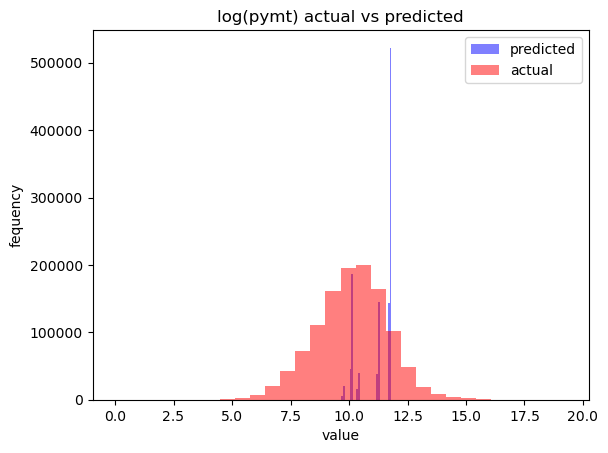

In [14]:
plt.hist(np.log(y_pred.apply(lambda x:x if x!=0 else 1)), bins=30, alpha=0.5, color="blue", label="predicted")
plt.hist(np.log(y_actual.apply(lambda x:x if x!=0 else 1)), bins=30, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

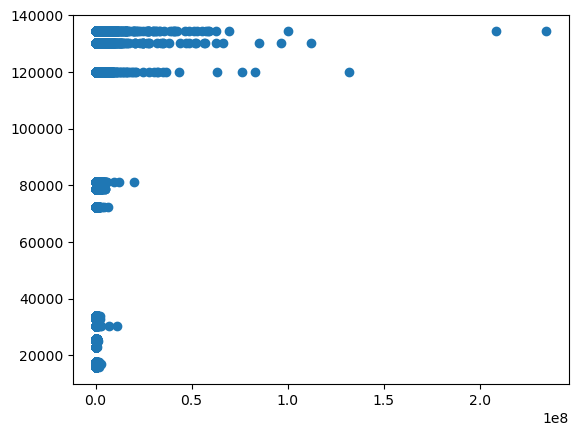

In [15]:
plt.scatter(y_actual,y_pred)

For individual data points, the model fails miserablly. But if we only care about the total pymt amount, it performs pretty good.